## Step 1: Import Libraries

In [56]:
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.20.0


## Step 2: Load and Preprocess the Dataset (Synthetic Regression — 10,000 samples)

In [57]:
from sklearn.datasets import make_regression

# Generate a large synthetic regression dataset (~10,000 samples)
X, y = make_regression(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    noise=30,
    random_state=42
)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Target range before scaling: [{y.min():.1f}, {y.max():.1f}]")

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features AND targets using StandardScaler
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"Target range after scaling:  [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("Data preprocessing complete.")

Dataset shape: X=(10000, 20), y=(10000,)
Target range before scaling: [-936.5, 975.2]
Target range after scaling:  [-3.73, 3.87]

Train size: 8000, Test size: 2000
Data preprocessing complete.


In [58]:
input_dim = X_train.shape[1]  # 20 features

# -----------------------------------------------------------
# Model A: No Batch Normalization | Optimizer: SGD
# -----------------------------------------------------------
model_a = tf.keras.Sequential([
    tf.keras.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
], name="Model_A_NoBN")

model_a.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='mse'
)

# -----------------------------------------------------------
# Model B: With Batch Normalization | Optimizer: Adam
# -----------------------------------------------------------
model_b = tf.keras.Sequential([
    tf.keras.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(32),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(1)
], name="Model_B_WithBN")

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

print("Model A (No BN | SGD):")
model_a.summary()

print("\nModel B (Batch Norm | Adam):")
model_b.summary()

Model A (No BN | SGD):


Model: "Model_A_NoBN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

...

Model: "Model_B_WithBN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)

In [59]:
EPOCHS = 30

# Train Model A (No BN | SGD)
print("Training Model A (No BN | SGD)...")
start = time.time()
history_a = model_a.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, verbose=0)
time_a = time.time() - start
print(f"  Done. Final loss: {history_a.history['loss'][-1]:.4f} | Time: {time_a:.3f}s")

# Train Model B (Batch Norm | Adam)
print("\nTraining Model B (Batch Norm | Adam)...")
start = time.time()
history_b = model_b.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, verbose=0)
time_b = time.time() - start
print(f"  Done. Final loss: {history_b.history['loss'][-1]:.4f} | Time: {time_b:.3f}s")

print("\nTraining complete.")

Training Model A (No BN | SGD)...
  Done. Final loss: 0.0138 | Time: 2.258s

Training Model B (Batch Norm | Adam)...
  Done. Final loss: 0.0547 | Time: 2.834s

Training complete.


## Step 5: Plot Training Loss Curves

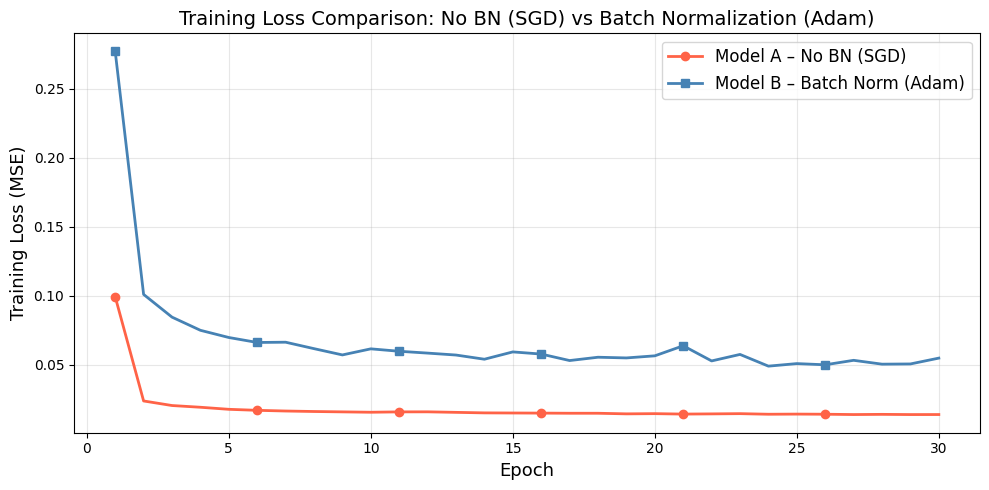

In [60]:
loss_a = history_a.history['loss']
loss_b = history_b.history['loss']

plt.figure(figsize=(10, 5))

plt.plot(range(1, EPOCHS + 1), loss_a, label='Model A – No BN (SGD)',
         color='tomato', linewidth=2, marker='o', markevery=5)
plt.plot(range(1, EPOCHS + 1), loss_b, label='Model B – Batch Norm (Adam)',
         color='steelblue', linewidth=2, marker='s', markevery=5)

plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Training Loss (MSE)', fontsize=13)
plt.title('Training Loss Comparison: No BN (SGD) vs Batch Normalization (Adam)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Compare Final Performance (MSE + Training Time)

In [61]:
mse_a = model_a.evaluate(X_test, y_test, verbose=0)
mse_b = model_b.evaluate(X_test, y_test, verbose=0)

print("=" * 55)
print(f"{'Metric':<30} {'Model A':>10} {'Model B':>10}")
print(f"{'':30} {'(No BN/SGD)':>10} {'(BN/Adam)':>10}")
print("-" * 55)
print(f"{'Test MSE':<30} {mse_a:>10.2f} {mse_b:>10.2f}")
print(f"{'Final Train Loss':<30} {loss_a[-1]:>10.4f} {loss_b[-1]:>10.4f}")
print(f"{'Training Time (s)':<30} {time_a:>10.3f} {time_b:>10.3f}")
print("=" * 55)

winner = "Model B (BN + Adam)" if mse_b < mse_a else "Model A (No BN + SGD)"
print(f"\nBetter Test MSE: {winner}")

Metric                            Model A    Model B
                               (No BN/SGD)  (BN/Adam)
-------------------------------------------------------
Test MSE                             0.02       0.02
Final Train Loss                   0.0138     0.0547
Training Time (s)                   2.258      2.834

Better Test MSE: Model A (No BN + SGD)


---
## Complete Solution (All-in-One)

Dataset : 10,000 samples | 20 features
Train   : 8000  |  Test : 2000
Target range (scaled): [-3.73, 3.87]

Model A params: 3457
Model B params: 3841 

Model A final train loss : 0.0138
Model B final train loss : 0.0555



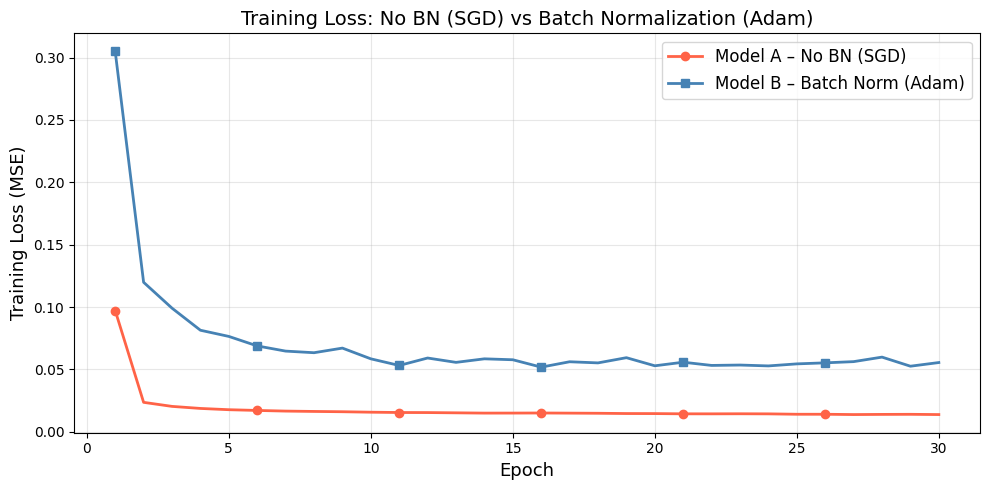

Metric                            Model A    Model B
                               (No BN/SGD)  (BN/Adam)
-------------------------------------------------------
Test MSE                           0.0184     0.0206
Final Train Loss                   0.0138     0.0555
Training Time (s)                   2.135      2.794

Better Test MSE: Model A (No BN + SGD)


In [62]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# ── 1. DATA ──────────────────────────────────────────────────────────────────
X, y = make_regression(n_samples=10000, n_features=20,
                       n_informative=15, noise=30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sx = StandardScaler(); X_train = sx.fit_transform(X_train); X_test = sx.transform(X_test)
sy = StandardScaler(); y_train = sy.fit_transform(y_train.reshape(-1,1)).ravel()
y_test = sy.transform(y_test.reshape(-1,1)).ravel()

print(f"Dataset : 10,000 samples | 20 features")
print(f"Train   : {X_train.shape[0]}  |  Test : {X_test.shape[0]}")
print(f"Target range (scaled): [{y_train.min():.2f}, {y_train.max():.2f}]\n")

# ── 2. MODELS ─────────────────────────────────────────────────────────────────
d = X_train.shape[1]

model_a = tf.keras.Sequential([
    tf.keras.Input(shape=(d,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
], name="Model_A_NoBN")
model_a.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), loss='mse')

model_b = tf.keras.Sequential([
    tf.keras.Input(shape=(d,)),
    tf.keras.layers.Dense(64),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(32),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(1)
], name="Model_B_WithBN")
model_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

print("Model A params:", model_a.count_params())
print("Model B params:", model_b.count_params(), "\n")

# ── 3. TRAINING (30 epochs) ───────────────────────────────────────────────────
EPOCHS = 30

t0 = time.time()
hist_a = model_a.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, verbose=0)
time_a = time.time() - t0

t0 = time.time()
hist_b = model_b.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, verbose=0)
time_b = time.time() - t0

loss_a = hist_a.history['loss']
loss_b = hist_b.history['loss']
print(f"Model A final train loss : {loss_a[-1]:.4f}")
print(f"Model B final train loss : {loss_b[-1]:.4f}\n")

# ── 4. PLOT LOSS CURVES ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), loss_a, label='Model A – No BN (SGD)',
         color='tomato',    linewidth=2, marker='o', markevery=5)
plt.plot(range(1, EPOCHS+1), loss_b, label='Model B – Batch Norm (Adam)',
         color='steelblue', linewidth=2, marker='s', markevery=5)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Training Loss (MSE)', fontsize=13)
plt.title('Training Loss: No BN (SGD) vs Batch Normalization (Adam)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 5. FINAL PERFORMANCE ──────────────────────────────────────────────────────
mse_a = model_a.evaluate(X_test, y_test, verbose=0)
mse_b = model_b.evaluate(X_test, y_test, verbose=0)

print("=" * 55)
print(f"{'Metric':<30} {'Model A':>10} {'Model B':>10}")
print(f"{'':30} {'(No BN/SGD)':>10} {'(BN/Adam)':>10}")
print("-" * 55)
print(f"{'Test MSE':<30} {mse_a:>10.4f} {mse_b:>10.4f}")
print(f"{'Final Train Loss':<30} {loss_a[-1]:>10.4f} {loss_b[-1]:>10.4f}")
print(f"{'Training Time (s)':<30} {time_a:>10.3f} {time_b:>10.3f}")
print("=" * 55)
winner = "Model B (BN + Adam)" if mse_b < mse_a else "Model A (No BN + SGD)"
print(f"\nBetter Test MSE: {winner}")